✓ Ready
Loading: C:\python\Intelligent_Sketch2CAD\intermediate_data\adaptive_cleaned_20260510_143013.jpg
Main contour area: 708012 px
Kept: 1565 inside, 553 near edge


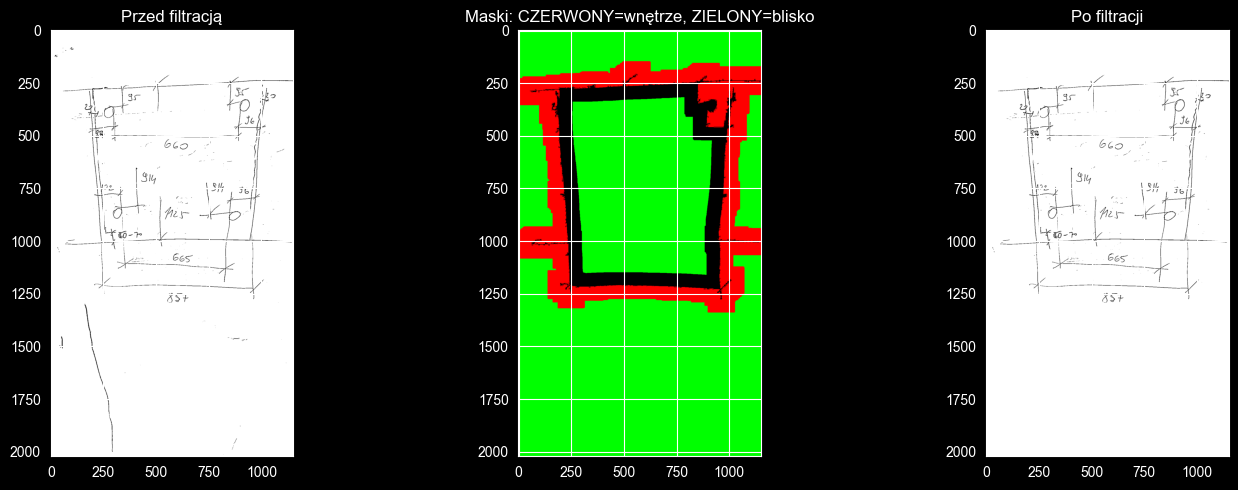


--- Thinning (szkieletowanie) ---


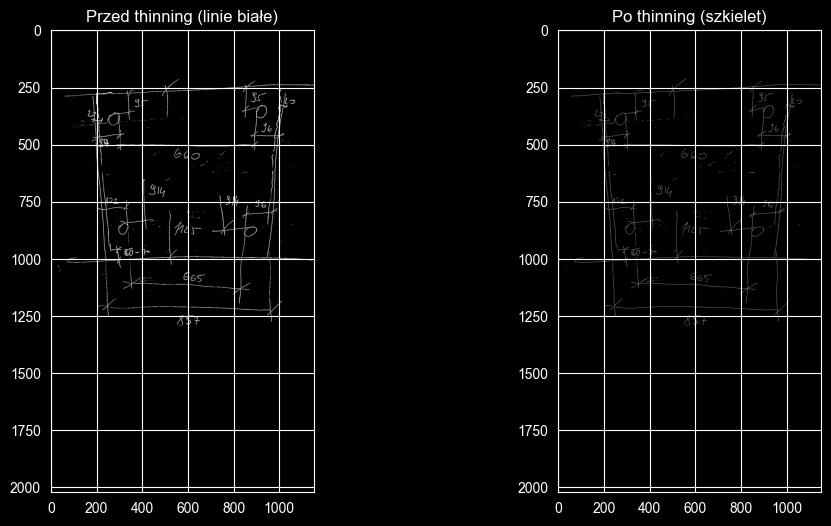

Znaleziono konturów na szkielecie: 348

--- Wyniki detekcji linii (po thinning) ---
Linie główne (poziome/pionowe): 0
Ticki (45°): 0
Inne linie proste: 1
Po scalaniu linie główne: 0

--- Detekcja okręgów ---
Okręgi z HoughCircles: 48
Bloby (cyfry, małe obiekty): 284

--- Graf ---
Węzłów: 0
Krawędzi (linie główne + ticki): 0
Węzłów narożnych (stopień≥2): 0


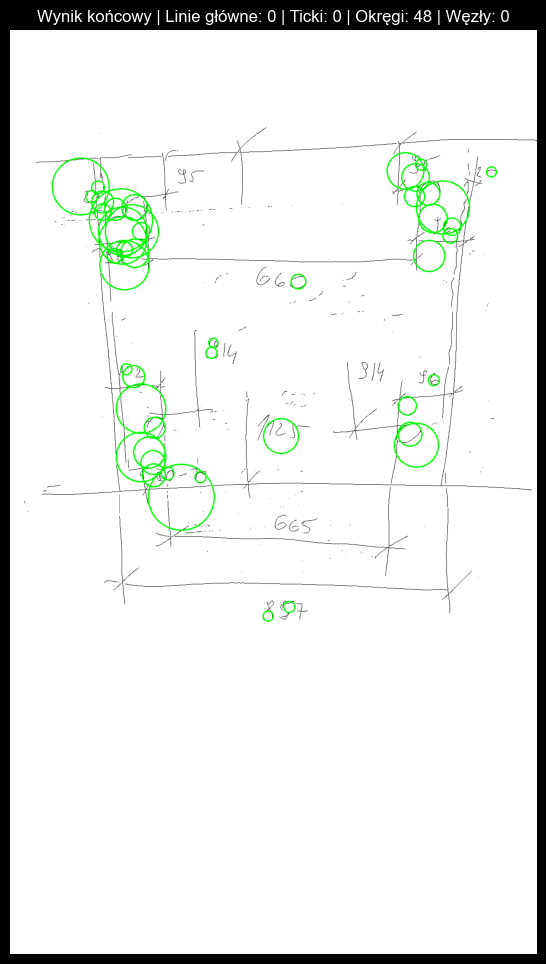

TypeError: Object of type int32 is not JSON serializable

In [2]:
# -------------------------------
# VERTICAL SLICE: SKETCH → TECHNICAL DRAWING
# Metoda: preprocessing → thinning → kontury → aproksymacja → klasyfikacja
# -------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os
import json
from datetime import datetime
from collections import defaultdict

print("✓ Ready")

# -------------------------------
# PATHS
# -------------------------------
PROJECT_DIR = Path(r"C:\python\Intelligent_Sketch2CAD")
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"
INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------
# LOAD LATEST adaptive_cleaned_*.jpg
# -------------------------------
pattern = str(INTERMEDIATE_DIR / "adaptive_cleaned_*.jpg")
files = glob.glob(pattern)
latest_file = max(files, key=os.path.getctime)
print(f"Loading: {latest_file}")

image = cv2.imread(latest_file)
if len(image.shape) == 3:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
else:
    gray = image

# Polaryzacja: białe tło, czarne linie (upewniamy się)
if np.mean(gray) < 128:
    gray = cv2.bitwise_not(gray)
    print("Polarity fixed (white background, black lines)")

# ============================================================
# PREPROCESSING – taki sam jak wcześniej (filtracja komponentów)
# ============================================================
contour_img = cv2.bitwise_not(gray)
contours, _ = cv2.findContours(contour_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
    print("No contours found – keeping original")
    gray_filtered = gray
else:
    main_contour = max(contours, key=cv2.contourArea)
    area_main = cv2.contourArea(main_contour)
    print(f"Main contour area: {area_main:.0f} px")

    mask_inside = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_inside, [main_contour], -1, 255, thickness=cv2.FILLED)

    mask_edge = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_edge, [main_contour], -1, 255, thickness=2)
    kernel_large = np.ones((120, 120), np.uint8)
    mask_near = cv2.dilate(mask_edge, kernel_large, iterations=1)
    mask_near_or_bottom = mask_near

    cc_img = cv2.bitwise_not(gray)
    _, labels, stats, _ = cv2.connectedComponentsWithStats(cc_img, connectivity=8)

    mask_final = np.zeros_like(gray, dtype=np.uint8)
    MAX_AREA_SMALL = 1500
    kept_inside = 0
    kept_near = 0

    for label in range(1, len(stats)):
        comp_mask = (labels == label).astype(np.uint8) * 255
        area = stats[label, cv2.CC_STAT_AREA]

        if cv2.bitwise_and(comp_mask, mask_inside).any():
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
            kept_inside += 1
            continue

        in_near = cv2.bitwise_and(comp_mask, mask_near_or_bottom)
        if in_near.any() and area < MAX_AREA_SMALL:
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
            kept_near += 1
            continue

    print(f"Kept: {kept_inside} inside, {kept_near} near edge")

    gray_filtered = cv2.bitwise_and(gray, mask_final)
    gray_filtered[mask_final == 0] = 255

    # Wizualizacja filtrów
    plt.figure(figsize=(15, 5))
    plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.title("Przed filtracją")
    plt.subplot(1,3,2)
    viz = np.zeros((*gray.shape, 3), dtype=np.uint8)
    viz[mask_inside==0] = [255,0,0]
    viz[mask_near_or_bottom == 0] = [0,255,0]
    plt.imshow(viz)
    plt.title("Maski: CZERWONY=wnętrze, ZIELONY=blisko")
    plt.subplot(1,3,3); plt.imshow(gray_filtered, cmap='gray'); plt.title("Po filtracji")
    plt.tight_layout()
    plt.show()

    gray = gray_filtered

# ============================================================
# THINNING (szkieletowanie) – linie stają się 1 piksel grube
# ============================================================
print("\n--- Thinning (szkieletowanie) ---")
# Przygotuj obraz: linie białe (255), tło czarne (0) – wymagane przez thinning
binary_thin = cv2.bitwise_not(gray)   # teraz linie białe na czarnym tle
skeleton = cv2.ximgproc.thinning(binary_thin, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)

# Odwróć z powrotem dla wygody (linie czarne na białym tle) do dalszej obróbki
skeleton_inv = cv2.bitwise_not(skeleton)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(binary_thin, cmap='gray'); plt.title("Przed thinning (linie białe)")
plt.subplot(1,2,2); plt.imshow(skeleton, cmap='gray'); plt.title("Po thinning (szkielet)")
plt.show()

# ============================================================
# DETEKCJA WSZYSTKICH KONTURÓW NA SZKIELECIE
# ============================================================
# Kontury na szkielecie (linie białe na czarnym tle)
contours_skeleton, _ = cv2.findContours(skeleton, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
print(f"Znaleziono konturów na szkielecie: {len(contours_skeleton)}")

# ============================================================
# APROKSYMACJA I KLASYFIKACJA LINII
# ============================================================
MIN_CONTOUR_LEN = 15   # pikseli (minimalna długość konturu)
lines_main = []   # długie poziome/pionowe
lines_ticks = []  # krótkie 45°
lines_other = []  # pozostałe linie proste (np. ukośne nie-ticki)

for cnt in contours_skeleton:
    perimeter = cv2.arcLength(cnt, closed=False)   # dla otwartych konturów
    if perimeter < MIN_CONTOUR_LEN:
        continue

    # Aproksymacja prostą (Douglas-Peucker)
    epsilon = 0.01 * perimeter   # 1% długości
    approx = cv2.approxPolyDP(cnt, epsilon, closed=False)

    if len(approx) == 2:
        x1, y1 = approx[0][0]
        x2, y2 = approx[1][0]
        length = np.hypot(x2-x1, y2-y1)
        angle = np.degrees(np.arctan2(y2-y1, x2-x1)) % 180

        # Klasyfikacja
        if length > 80 and (angle < 15 or angle > 165 or (75 < angle < 105)):
            lines_main.append([int(x1), int(y1), int(x2), int(y2)])
        elif 15 <= length <= 70 and ((35 < angle < 55) or (125 < angle < 145)):
            lines_ticks.append([int(x1), int(y1), int(x2), int(y2)])
        else:
            lines_other.append([int(x1), int(y1), int(x2), int(y2)])
    else:
        # Jeśli kontur nie jest prosty – może to być okrąg lub kształt, pomijamy w liniach
        pass

print("\n--- Wyniki detekcji linii (po thinning) ---")
print(f"Linie główne (poziome/pionowe): {len(lines_main)}")
print(f"Ticki (45°): {len(lines_ticks)}")
print(f"Inne linie proste: {len(lines_other)}")

# Opcjonalne scalanie współliniowych odcinków (prosta heurystyka)
def merge_collinear(segments, angle_thresh=10, dist_thresh=15):
    if len(segments) < 2:
        return segments
    merged = []
    used = [False]*len(segments)
    for i, s1 in enumerate(segments):
        if used[i]:
            continue
        x1,y1,x2,y2 = s1
        angle1 = np.degrees(np.arctan2(y2-y1, x2-x1)) % 180
        current = [x1,y1,x2,y2]
        used[i] = True
        for j, s2 in enumerate(segments):
            if used[j]:
                continue
            x3,y3,x4,y4 = s2
            angle2 = np.degrees(np.arctan2(y4-y3, x4-x3)) % 180
            if abs(angle1 - angle2) > angle_thresh:
                continue
            # Sprawdź odległość między końcami
            ends = [(x1,y1), (x2,y2), (x3,y3), (x4,y4)]
            # Prosta heurystyka: jeśli któryś koniec jest blisko innego końca
            merged_flag = False
            for (px,py) in [(x1,y1),(x2,y2)]:
                for (qx,qy) in [(x3,y3),(x4,y4)]:
                    if np.hypot(px-qx, py-qy) < dist_thresh:
                        # scal: nowe końce to min i max rzutowane na wspólną linię
                        all_pts = [(x1,y1), (x2,y2), (x3,y3), (x4,y4)]
                        # uśrednij kąt
                        angle_avg = angle1
                        # rzutuj punkty na prostą o kącie angle_avg przechodzącą przez środek
                        # uproszczone: weź min i max wzdłuż kierunku
                        # (można zrobić dokładniej, ale na dziś wystarczy)
                        xs = [p[0] for p in all_pts]
                        ys = [p[1] for p in all_pts]
                        if abs(angle_avg) < 45 or abs(angle_avg-180) < 45:
                            y_med = np.median(ys)
                            current = [min(xs), int(y_med), max(xs), int(y_med)]
                        else:
                            x_med = np.median(xs)
                            current = [int(x_med), min(ys), int(x_med), max(ys)]
                        merged_flag = True
                        used[j] = True
                        break
                if merged_flag:
                    break
        merged.append(current)
    return merged

# Scal główne linie
lines_main = merge_collinear(lines_main, angle_thresh=8, dist_thresh=20)
print(f"Po scalaniu linie główne: {len(lines_main)}")

# ============================================================
# DETEKCJA OKRĘGÓW (próba HoughCircles + weryfikacja konturami)
# ============================================================
print("\n--- Detekcja okręgów ---")
# Użyjemy oryginalnego obrazu (gray) przed thinning – białe tło, czarne linie
gray_original = gray  # z preprocessing

# HoughCircles
circles_hough = []
dp = 1
minDist = 20
param1 = 100   # większy dla lepszej detekcji krawędzi
param2 = 20    # mniejszy = więcej wykryć
minRadius = 5
maxRadius = 80

circles = cv2.HoughCircles(gray_original, cv2.HOUGH_GRADIENT, dp, minDist,
                           param1=param1, param2=param2,
                           minRadius=minRadius, maxRadius=maxRadius)

if circles is not None:
    circles = np.round(circles[0, :]).astype("int")
    for (x, y, r) in circles:
        # Sprawdź pokrycie (ile czarnych pikseli na obwodzie)
        mask_circ = np.zeros_like(gray_original, dtype=np.uint8)
        cv2.circle(mask_circ, (x, y), r, 255, 2)
        overlap = cv2.bitwise_and(gray_original, mask_circ)
        coverage = np.sum(overlap == 0) / (np.sum(mask_circ == 255) + 1e-6)
        if coverage > 0.5:
            circles_hough.append([x, y, r])
print(f"Okręgi z HoughCircles: {len(circles_hough)}")

# Jeśli nie znaleziono, spróbuj przez analizę konturów na oryginalnym obrazie
if len(circles_hough) == 0:
    print("Próbuję wykryć okręgi przez kontury...")
    binary_white_lines = cv2.bitwise_not(gray_original)  # linie białe
    contours_orig, _ = cv2.findContours(binary_white_lines, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours_orig:
        perimeter = cv2.arcLength(cnt, True)
        if perimeter < 30: continue
        area = cv2.contourArea(cnt)
        circularity = 4 * np.pi * area / (perimeter * perimeter)
        if circularity > 0.7 and 20 < perimeter < 300:
            (x, y), radius = cv2.minEnclosingCircle(cnt)
            circles_hough.append([int(x), int(y), int(radius)])
    print(f"Okręgi z konturów: {len(circles_hough)}")

# ============================================================
# BLOBY (cyfry, małe elementy) – z oryginalnego gray (przed thinning)
# ============================================================
blobs = []
binary_blobs = cv2.bitwise_not(gray_original)
contours_blobs, _ = cv2.findContours(binary_blobs, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
for cnt in contours_blobs:
    area = cv2.contourArea(cnt)
    if area < 20 or area > 800:  # zakres typowy dla cyfr i małych elementów
        continue
    perimeter = cv2.arcLength(cnt, True)
    circularity = 4 * np.pi * area / (perimeter * perimeter) if perimeter > 0 else 0
    # Pomijamy okręgi (już wykryte)
    if circularity > 0.7:
        continue
    x, y, w, h = cv2.boundingRect(cnt)
    blobs.append({"bbox": [int(x), int(y), int(w), int(h)], "area": int(area)})
print(f"Bloby (cyfry, małe obiekty): {len(blobs)}")

# ============================================================
# BUDOWANIE WĘZŁÓW I KRAWĘDZI (dla linii głównych i ticków)
# ============================================================
proximity_threshold = 12
nodes = []  # (x,y)
edges = []  # (node1, node2, typ, line_idx)

def find_or_add_node(x, y):
    for i, (nx, ny) in enumerate(nodes):
        if abs(nx - x) < proximity_threshold and abs(ny - y) < proximity_threshold:
            return i
    nodes.append((int(x), int(y)))
    return len(nodes)-1

# Dodaj linie główne
for idx, (x1,y1,x2,y2) in enumerate(lines_main):
    n1 = find_or_add_node(x1, y1)
    n2 = find_or_add_node(x2, y2)
    edges.append((n1, n2, "main", idx))
# Dodaj ticki
for idx, (x1,y1,x2,y2) in enumerate(lines_ticks):
    n1 = find_or_add_node(x1, y1)
    n2 = find_or_add_node(x2, y2)
    edges.append((n1, n2, "tick", idx))

node_degree = defaultdict(int)
for e in edges:
    node_degree[e[0]] += 1
    node_degree[e[1]] += 1
corner_nodes = [i for i, deg in node_degree.items() if deg >= 2]

print(f"\n--- Graf ---")
print(f"Węzłów: {len(nodes)}")
print(f"Krawędzi (linie główne + ticki): {len(edges)}")
print(f"Węzłów narożnych (stopień≥2): {len(corner_nodes)}")

# ============================================================
# WIZUALIZACJA KOŃCOWA
# ============================================================
vis = cv2.cvtColor(skeleton_inv, cv2.COLOR_GRAY2BGR)  # użyj szkieletu jako tła
# Linie główne – niebieskie
for (x1,y1,x2,y2) in lines_main:
    cv2.line(vis, (x1,y1), (x2,y2), (255,0,0), 2)
# Ticki – żółte
for (x1,y1,x2,y2) in lines_ticks:
    cv2.line(vis, (x1,y1), (x2,y2), (0,255,255), 2)
# Inne linie – fioletowe (opcjonalnie)
for (x1,y1,x2,y2) in lines_other:
    cv2.line(vis, (x1,y1), (x2,y2), (255,0,255), 1)
# Okręgi – zielone
for (x,y,r) in circles_hough:
    cv2.circle(vis, (x,y), r, (0,255,0), 2)
# Węzły – czerwone kropki
for i, (x,y) in enumerate(nodes):
    color = (0,0,255) if i in corner_nodes else (255,0,0)
    cv2.circle(vis, (x,y), 4, color, -1)

plt.figure(figsize=(14,12))
plt.imshow(vis)
plt.title(f"Wynik końcowy | Linie główne: {len(lines_main)} | Ticki: {len(lines_ticks)} | Okręgi: {len(circles_hough)} | Węzły: {len(nodes)}")
plt.axis('off')
plt.show()

# ============================================================
# ZAPIS DO JSON
# ============================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
data = {
    "timestamp": timestamp,
    "source_image": str(latest_file),
    "method": "thinning + contours",
    "image_shape": list(gray.shape),
    "statistics": {
        "main_lines": len(lines_main),
        "ticks": len(lines_ticks),
        "other_lines": len(lines_other),
        "circles": len(circles_hough),
        "blobs": len(blobs),
        "nodes": len(nodes),
        "edges": len(edges)
    },
    "lines": {
        "main": lines_main,
        "ticks": lines_ticks,
        "other": lines_other
    },
    "circles": circles_hough,
    "blobs": blobs,
    "graph": {
        "nodes": nodes,
        "edges": edges,
        "corner_nodes": corner_nodes
    }
}

json_path = INTERMEDIATE_DIR / f"thinning_result_{timestamp}.json"
with open(json_path, 'w') as f:
    json.dump(data, f, indent=2)

# Zapisz wizualizację końcową
final_img_path = INTERMEDIATE_DIR / f"thinning_result_{timestamp}.jpg"
cv2.imwrite(str(final_img_path), cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))

print(f"\n✅ Zapisano:")
print(f"   JSON: {json_path}")
print(f"   Obraz: {final_img_path}")
print("\nGotowe do importu do FreeCAD – uzyj 'lines['main']' i 'circles'")